In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Literal,Annotated
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
import operator

from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [3]:
class ChatState(TypedDict):
    
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state:ChatState):
    
    messages = state['messages']
    
    response = llm.invoke(messages)
    
    return {'messages':[response]}

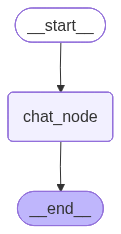

In [5]:
graph = StateGraph(ChatState)

# add node
graph.add_node('chat_node', chat_node)


#add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot= graph.compile()

chatbot

In [6]:
initial_state = {
    "messages": [HumanMessage(content='What is the capital of India?')]

}
chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='200c9476-ed8b-4ecf-bff1-83f9b98a358f'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 42, 'total_tokens': 51, 'completion_time': 0.012680204, 'completion_tokens_details': None, 'prompt_time': 0.001197713, 'prompt_tokens_details': None, 'queue_time': 0.057677686, 'total_time': 0.013877917}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ef2cb-afb6-75c1-9d46-34c736f8f91a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 9, 'total_tokens': 51})]}

In [7]:
initial_state = {
    "messages": [HumanMessage(content='What is the capital of India?')]

}
chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is New Delhi.'

# Chatbot

In [8]:
while True:
    user_message = input("Type here: ")
    
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})
    
    print('AI:', response['messages'][-1].content)

AI: It's nice to meet you. Is there something I can help you with or would you like to chat?
AI: The capital of India is **New Delhi**.
AI: The language of China is Mandarin Chinese. It is the official language and the most widely spoken language in China, with over 1 billion speakers. Mandarin Chinese is a member of the Sino-Tibetan language family and is spoken in various dialects across the country.

Mandarin Chinese is the language used in government, education, media, and formal situations, while other dialects and languages, such as Cantonese, Wu, and Min, are spoken in different regions and communities.

Here are some interesting facts about the Chinese language:

* Chinese is a tonal language, which means that the same word can have different meanings based on the tone in which it is pronounced.
* Chinese characters (hanzi) are used to write the language, and there are thousands of characters to learn.
* Mandarin Chinese is the most widely spoken language in the world, with ove

# The problems in this Chatbot 

--- this is not having memeory or chat history to the context persistantce is zero here.... example is below

In [10]:
while True:
    user_message = input("Type here: ")
    
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})
    print('User:' ,user_message)
    print('AI:', response['messages'][-1].content)

User: Hi, my name is Narsingh
AI: Hello Narsingh, it's nice to meet you. Is there something I can help you with or would you like to chat?
User: What is y name, can you please tell me?
AI: I don't know your name. I'm a large language model, I don't have the ability to know your personal information or recall previous conversations. Each time you interact with me, it's a new conversation. If you'd like to share your name with me, I'd be happy to chat with you and use it in our conversation.
User: ok, can you add 10+25 
AI: 10 + 25 = 35
User: ok add 35 to this total
AI: There is no total to add 35 to. This is the start of our conversation. If you'd like to provide a number, I can add 35 to it for you.


### Problem ---- We are starting the flow again and again in this loop, we are starting again from the START

# `Persistance`

-- We will use here the concept of persistance from LangGraph by storing Chat History in either Database or in RAM

In [12]:
from langgraph.checkpoint.memory import MemorySaver

In [13]:
class ChatState(TypedDict):
    
    messages: Annotated[list[BaseMessage], add_messages]
    
    
    
def chat_node(state:ChatState):
    
    messages = state['messages']
    
    response = llm.invoke(messages)
    
    return {'messages':[response]}


checkpointer = MemorySaver()

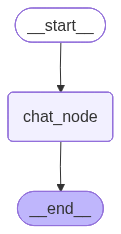

In [14]:
graph = StateGraph(ChatState)

# add node
graph.add_node('chat_node', chat_node)


#add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot= graph.compile(checkpointer=checkpointer)

chatbot

In [15]:
thread_id = '1'

while True:
    user_message = input("Type here: ")
    
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break
    config = {'configurable': {'thread_id':thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('User:' ,user_message)
    print('AI:', response['messages'][-1].content)

User: Hi, My name is Narsingh
AI: Hello Narsingh, it's nice to meet you. Is there something I can help you with or would you like to chat?
User: Can you tell me my Name?
AI: Your name is Narsingh.
User: Please add 10 with 25
AI: 25 + 10 = 35
User: ok multiple with 4 and tell me the total
AI: 35 * 4 = 140 

The total is 140.


In [ ]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi, My name is Narsingh', additional_kwargs={}, response_metadata={}, id='9ae68559-92e0-4200-abbd-a76c2596b618'), AIMessage(content="Hello Narsingh, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 43, 'total_tokens': 71, 'completion_time': 0.048769191, 'completion_tokens_details': None, 'prompt_time': 0.009200954, 'prompt_tokens_details': None, 'queue_time': 0.162682063, 'total_time': 0.057970145}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ef368-973f-71d0-b113-db4782206fd1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 43, 'output_tokens': 28, 'total_tokens': 71}), HumanMessage(content='Can you tell me my Name?', a

: 